# Task 4 — Customer Segmentation (v5)

**Dataset:** Consumer Financial Health & Engagement 2025 (synthetic, Vietnam). 999 consumers, customer-month grain (10,992 rows), plus the transaction file (1,852,394 rows).
**Goal:** group customers into distinct, actionable segments across financial health and engagement, validate them, profile them side by side, and give non-punitive business recommendations. `financial_health_score` is never used for credit decisions.

## Changelog vs `Customer_segment_v4.ipynb` (v4 is kept unchanged)
| # | Issue in v4 | Fix in v5 |
|---|---|---|
| 1 | "Quiet Achievers" (88) were exactly the customers with only 1-2 observed months (88/88), not a behaviour. Their bimodal age and the k=2 silhouette peak were side-effects of this. | K-Means runs on the **908 full-year customers**. The 91 partial-year customers form a rule-based segment, *New / Low-history*. Coverage is still 100%. |
| 2 | The Financial Health Index treated a **high essential ratio as bad**. In the data it goes with better health, so "Healthy" labels were wrong. | Direction fixed. The index's correlation with the given score is reported, and segment names follow the given `financial_health_score`. |
| 3 | The transaction file used had been truncated by Excel (1,048,576 rows, months 1-8, 966 customers), and the notebook claimed the dataset itself was corrupted. | The original CSV is used (1,852,394 rows, months 1-12, 999 customers). The rhythm-feature test is re-run on complete data, and the corruption claims are removed. |
| 4 | `next_month_low_health_flag` was described as "low health". It equals *next month's score < 40* (crisis) and is derived from the same ratios. | Replaced by the **share of months with score < 60**. The flag is reported only as a descriptive crisis rate. |
| 5 | "Two methods converge", with no elbow chart and no stability test | Adjusted Rand Index vs a rule-based 2×2 matrix, an elbow chart, seed and bootstrap stability tests |
| 6 | Demographics cell had no output; occupation not profiled; Limitation #6 contradicted §3.1 | Demographics are computed and printed. Occupation uses the 10 keyword groups from Task 2. Limitations rewritten. |
| 8 | `balance_trend_norm` is a near-duplicate of spend-to-income (r = -0.998), so spend pressure was counted twice | Dropped from the model (v4's own 0.95 duplicate threshold); kept for profiling |
| 9 | PCA components were kept by a hand-picked variance threshold | Kaiser criterion (eigenvalue > 1): 2 financial + 2 engagement components |
| 7 | Business recommendations removed, although the brief requires them | §4 adds non-punitive recommendations per segment, sized from the data |

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, HDBSCAN
from sklearn.metrics import silhouette_score, adjusted_rand_score

pd.set_option("display.max_columns", None); pd.set_option("display.width", 200)
ROOT = Path.cwd() if (Path.cwd() / "BI10_ROUND01_DATASET").exists() else Path.cwd().parent
RAW = ROOT / "BI10_ROUND01_DATASET"
OUT = ROOT / "outputs_task4"; OUT.mkdir(exist_ok=True)

# Same palette as the Task 1-3 notebook so slides look consistent
BLUE, ORANGE, AQUA, VIOLET, GRAY, INK, INK_2 = "#2a78d6", "#eb6834", "#1baf7a", "#4a3aa7", "#b5b4ab", "#0b0b0b", "#52514e"
plt.rcParams.update({"font.family": ["Segoe UI", "DejaVu Sans"], "font.size": 10, "axes.titlesize": 11.5,
                     "axes.titleweight": "bold", "axes.titlelocation": "left", "axes.spines.top": False,
                     "axes.spines.right": False, "axes.grid": True, "grid.color": "#e1e0d9", "axes.axisbelow": True,
                     "legend.frameon": False, "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb"})
SOURCE = "Source: ITB synthetic Consumer Financial Health & Engagement 2025 dataset; team analysis."
def finish(fig, title, note=None):
    fig.suptitle(title, x=0.01, ha="left", fontsize=13.5, fontweight="bold")
    fig.text(0.01, -0.02, (note + "\n" if note else "") + SOURCE, fontsize=7.5, color="#898781", va="top")
    plt.show()

## 1. Data Preprocessing & Feature Engineering
### 1.1 Load and inspect the customer-month data

In [2]:
df = pd.read_csv(RAW / "consumer_financial_health_engagement_2025.csv", parse_dates=["analysis_month"])
df = df.sort_values(["consumer_id", "analysis_month"])
months = df.groupby("consumer_id").size()
print("Shape:", df.shape, "| consumers:", df.consumer_id.nunique())
print("Customers by observed months:", months.value_counts().sort_index().to_dict())
print("Missing values:", df.isna().sum()[df.isna().sum() > 0].to_dict(), "(last month of each customer, by design)")
# What the next-month flag really measures
nxt = df.groupby("consumer_id").financial_health_score.shift(-1)
ok = df.next_month_low_health_flag.notna() & nxt.notna()
print("next_month_low_health_flag == (next month's score < 40):",
      f"{((nxt[ok] < 40).astype(int) == df.next_month_low_health_flag[ok]).mean():.1%} of rows")

Shape: (10992, 30) | consumers: 999
Customers by observed months: {1: 86, 2: 5, 12: 908}
Missing values: {'next_month_low_health_flag': 999} (last month of each customer, by design)
next_month_low_health_flag == (next month's score < 40): 100.0% of rows


### 1.2 Aggregate to one row per customer
Monthly metrics are averaged over each customer's observed months. Two features are engineered:
- **`balance_trend_norm`** = (last ending balance − first opening balance) ÷ average monthly income
- **`low60_share`** = share of observed months with `financial_health_score` < 60 (Watch/Stressed). This is used for **validation and profiling only**, not as a clustering input.

> **FIX:** `full_year` flags the 908 customers with 12 observed months. A 1-2 month average is too noisy to cluster (see §2). `crisis_next_rate` keeps v4's flag under its real meaning (next month < 40).

In [3]:
first_bal = df.groupby("consumer_id").head(1).set_index("consumer_id").opening_balance_vnd
last_bal = df.groupby("consumer_id").tail(1).set_index("consumer_id").ending_balance_vnd
latest = df.groupby("consumer_id").tail(1).set_index("consumer_id")[["age", "gender", "occupation", "province_city"]]
cust = df.groupby("consumer_id").agg(
    n_months=("analysis_month", "count"), avg_income=("monthly_income_vnd", "mean"),
    total_spend=("total_spend_vnd", "sum"),
    avg_essential_ratio=("essential_spend_ratio", "mean"), avg_online_ratio=("online_spend_ratio", "mean"),
    avg_spend_income_ratio=("spend_to_income_ratio", "mean"), avg_utilization=("credit_utilization_ratio", "mean"),
    avg_volatility=("spending_volatility", "mean"), avg_txn_count=("transaction_count", "mean"),
    avg_active_days=("active_transaction_days", "mean"), avg_recency=("transaction_recency_days", "mean"),
    avg_category_diversity=("category_diversity", "mean"),
    avg_engagement_score=("engagement_score", "mean"), avg_health_score=("financial_health_score", "mean"),
    low60_share=("financial_health_score", lambda s: (s < 60).mean()),
    crisis_next_rate=("next_month_low_health_flag", "mean"),
).join(latest)
cust["balance_trend_norm"] = (last_bal - first_bal) / cust.avg_income
cust["crisis_next_rate"] = cust.crisis_next_rate.fillna(0)
cust["full_year"] = cust.n_months.eq(12)

# Occupation groups: same 10 keyword groups as Task 2 (outputs_fixed/tables/occupation_mapping.csv)
occ_path = ROOT / "outputs_fixed" / "tables" / "occupation_mapping.csv"
occ_map = pd.read_csv(occ_path).set_index("occupation").occupation_group if occ_path.exists() else pd.Series(dtype=str)
cust["occupation_group"] = cust.occupation.map(occ_map).fillna("Other")
cust["age_group"] = pd.cut(cust.age, [0, 17, 24, 34, 44, 54, 64, 200],
                           labels=["<18", "18-24", "25-34", "35-44", "45-54", "55-64", "65+"])
print("Customer table:", cust.shape, "| full-year:", int(cust.full_year.sum()), "| partial-year:", int((~cust.full_year).sum()),
      "| missing:", int(cust.isna().sum().sum()))

Customer table: (999, 24) | full-year: 908 | partial-year: 91 | missing: 0


### 1.3 Features for the two dimensions
The dataset's own `engagement_score` and `financial_health_score` are deliberately *not* used as inputs, so the segmentation can be cross-checked against them.

| Financial health dimension | Engagement dimension |
|---|---|
| `avg_spend_income_ratio` (↓ better) | `avg_txn_count` |
| `avg_utilization` (↓ better) | `avg_active_days` |
| `avg_essential_ratio` (**↑ better**, FIX) | `avg_online_ratio` (log) |
| `avg_volatility` (↓ better) | `avg_recency` (log, ↓ better) |
| ~~`balance_trend_norm`~~: dropped, r = 0.996 with spend-to-income (near-duplicate) | |

### 1.4 Skew, outliers and redundancy
Winsorising bounds (1st/99th percentile) and log transforms are fitted on the **full-year customers** (the modelling population). The same bounds are then applied to everyone.

In [4]:
FY = cust.full_year
def winsor_fit(s, lo=0.01, hi=0.99):
    a, b = s[FY].quantile(lo), s[FY].quantile(hi)
    return s.clip(a, b)

cust["avg_recency_log"] = np.log1p(cust.avg_recency)
cust["avg_online_ratio_log"] = np.log1p(cust.avg_online_ratio)
for f in ["avg_spend_income_ratio", "avg_utilization", "avg_essential_ratio", "avg_volatility", "balance_trend_norm"]:
    cust[f + "_w"] = winsor_fit(cust[f])

fin_features = ["avg_spend_income_ratio_w", "avg_utilization_w", "avg_essential_ratio_w", "avg_volatility_w"]
eng_features = ["avg_txn_count", "avg_active_days", "avg_online_ratio_log", "avg_recency_log"]
fin_direction = {"avg_spend_income_ratio_w": False, "avg_utilization_w": False,
                 "avg_essential_ratio_w": True,    # FIX: v4 had False; higher essential share goes with better health
                 "avg_volatility_w": False}
eng_direction = {"avg_txn_count": True, "avg_active_days": True, "avg_online_ratio_log": True, "avg_recency_log": False}

print("Skewness (full-year customers):", cust.loc[FY, fin_features + eng_features].skew().round(2).to_dict())
cc = cust.loc[FY, fin_features + eng_features].corr().abs().where(~np.eye(len(fin_features + eng_features), dtype=bool))
# FIX: balance_trend_norm is a near-duplicate of spend-to-income -> dropped from the model (kept for profiling)
r_bal = cust.loc[FY, "balance_trend_norm_w"].corr(cust.loc[FY, "avg_spend_income_ratio_w"])
print(f"balance_trend_norm vs spend-to-income: r = {r_bal:.3f} -> near-duplicate (>0.95), excluded from clustering")
print("Max |correlation| among model features:", round(cc.max().max(), 3), "->", cc.stack().idxmax())
print("Essential ratio vs given health score (Spearman, customer-months):",
      round(df.essential_spend_ratio.corr(df.financial_health_score, method="spearman"), 2))

Skewness (full-year customers): {'avg_spend_income_ratio_w': 0.09, 'avg_utilization_w': 0.51, 'avg_essential_ratio_w': -1.32, 'avg_volatility_w': 0.45, 'avg_txn_count': 0.5, 'avg_active_days': -1.13, 'avg_online_ratio_log': 0.5, 'avg_recency_log': 1.96}
balance_trend_norm vs spend-to-income: r = -0.998 -> near-duplicate (>0.95), excluded from clustering
Max |correlation| among model features: 0.782 -> ('avg_txn_count', 'avg_active_days')
Essential ratio vs given health score (Spearman, customer-months): 0.47


### 1.5 Composite indices (for interpretation and charts only)
Each feature is z-scored using full-year means/stds, sign-flipped where "higher is worse", averaged per dimension and rescaled to 0-100.

In [5]:
def zframe(frame, feats, direction=None):
    mu, sd = frame.loc[FY, feats].mean(), frame.loc[FY, feats].std()
    z = (frame[feats] - mu) / sd
    if direction:
        z = z * pd.Series({f: 1 if direction[f] else -1 for f in feats})
    return z

def to_100(s):
    lo, hi = s[FY].min(), s[FY].max()
    return ((s - lo) / (hi - lo) * 100).clip(0, 100)

cust["FinancialHealthIndex"] = to_100(zframe(cust, fin_features, fin_direction).mean(axis=1))
cust["EngagementIndex"] = to_100(zframe(cust, eng_features, eng_direction).mean(axis=1))
v4_dir = {**fin_direction, "avg_essential_ratio_w": False}
fhi_v4 = zframe(cust, fin_features, v4_dir).mean(axis=1)
print("Corr with given scores (full-year):")
print("  FinancialHealthIndex vs financial_health_score:", round(cust.loc[FY, "FinancialHealthIndex"].corr(cust.loc[FY, "avg_health_score"]), 3),
      f"(v4 direction: {fhi_v4[FY].corr(cust.loc[FY, 'avg_health_score']):.3f})")
print("  EngagementIndex vs engagement_score:          ", round(cust.loc[FY, "EngagementIndex"].corr(cust.loc[FY, "avg_engagement_score"]), 3))

Corr with given scores (full-year):
  FinancialHealthIndex vs financial_health_score: 0.893 (v4 direction: 0.761)
  EngagementIndex vs engagement_score:           0.941


### 1.6 Transaction rhythm features (candidate block)
> **FIX:** v4 read an Excel-truncated copy of the transaction file. The original CSV is complete: 1,852,394 rows, months 1-12, all 999 customers. No imputation is needed.

*Caveat:* in this synthetic data each spending category is generated in a fixed half-day window (see Task 1 Q4), so hour-of-day features mostly mirror category mix. They are tested fairly below, but not interpreted as real timing.

In [6]:
pq = ROOT / "data_cache_fixed" / "transactions.parquet"
cols = ["consumer_id", "transaction_month", "transaction_day_of_week", "transaction_hour"]
tx = pd.read_parquet(pq, columns=cols) if pq.exists() else pd.read_csv(RAW / "consumer_transactions_2025.csv", usecols=cols)
tx["consumer_id"] = tx.consumer_id.astype(str)
print("Transaction rows:", f"{len(tx):,}", "| months:", tx.transaction_month.min(), "-", tx.transaction_month.max(),
      "| customers:", tx.consumer_id.nunique(), "/ 999")
g = tx.groupby("consumer_id")
rhythm = pd.DataFrame({
    "weekend_ratio": g.transaction_day_of_week.apply(lambda d: d.isin([5, 6]).mean()),
    "night_ratio": g.transaction_hour.apply(lambda h: ((h >= 22) | (h < 6)).mean()),
    "hour_mean": g.transaction_hour.mean(),
    "hour_std": g.transaction_hour.std(),
    "dow_nunique": g.transaction_day_of_week.nunique(),
})
cust = cust.join(rhythm)
print("Customers without rhythm data:", int(cust.weekend_ratio.isna().sum()))
cust["hour_std"] = cust.hour_std.fillna(0)   # single-transaction customers
cust["weekend_ratio_log"] = np.log1p(cust.weekend_ratio); cust["night_ratio_log"] = np.log1p(cust.night_ratio)
cust["hour_std_w"] = winsor_fit(cust.hour_std)
rhythm_features = ["weekend_ratio_log", "night_ratio_log", "hour_mean", "hour_std_w", "dow_nunique"]
const = [f for f in rhythm_features if cust.loc[FY, f].nunique() == 1]
print("Constant among full-year customers (dropped):", {f: cust.loc[FY, f].iloc[0] for f in const})
rhythm_features = [f for f in rhythm_features if f not in const]
print("Skew (full-year):", cust.loc[FY, rhythm_features].skew().round(2).to_dict())

Transaction rows: 1,852,394 | months: 1 - 12 | customers: 999 / 999
Customers without rhythm data: 0
Constant among full-year customers (dropped): {'dow_nunique': np.int64(7)}
Skew (full-year): {'weekend_ratio_log': 1.42, 'night_ratio_log': -0.02, 'hour_mean': 0.01, 'hour_std_w': -1.02}


## 2. Model Selection, Setup, Implementation & Validation
### 2.1 Modelling population
> **FIX:** v4 clustered all 999 customers. Its "Quiet Achievers" cluster (88) consisted **only** of customers with 1-2 observed months, so K-Means was separating *data length*, not behaviour. v5 clusters the **908 full-year customers**. The **91 partial-year customers** are assigned by rule to *New / Low-history*, which keeps 100% coverage.

### 2.2 PCA within each block, then equal block weights
Each block is reduced with PCA, keeping components with eigenvalue > 1 (Kaiser criterion on standardised features). The components are standardised and divided by √(number of components), so every block contributes exactly one unit of variance to the distance.

In [7]:
fy = cust[FY].copy()
def block(feats, direction=None, name=""):
    z = zframe(fy, feats, direction)
    p = PCA(random_state=42).fit(z)
    n = int((p.explained_variance_ > 1).sum())   # Kaiser criterion
    pcs = PCA(n_components=n, random_state=42).fit_transform(z)
    print(f"{name:<10} eigenvalues {np.round(p.explained_variance_, 2)} | cumulative {np.round(np.cumsum(p.explained_variance_ratio_), 3)} -> keep {n}")
    return StandardScaler().fit_transform(pcs) / np.sqrt(n)

fin_b = block(fin_features, fin_direction, "Financial")
eng_b = block(eng_features, eng_direction, "Engagement")
rhy_b = block(rhythm_features, None, "Rhythm")
X_final = np.hstack([fin_b, eng_b])
X_rhythm = np.hstack([fin_b, eng_b, rhy_b])
print("Block variances:", [round(b.var(axis=0).sum(), 3) for b in (fin_b, eng_b, rhy_b)])

Financial  eigenvalues [1.72 1.3  0.71 0.28] | cumulative [0.429 0.753 0.929 1.   ] -> keep 2
Engagement eigenvalues [2.4  1.01 0.42 0.17] | cumulative [0.599 0.852 0.957 1.   ] -> keep 2
Rhythm     eigenvalues [2.87 0.94 0.15 0.03] | cumulative [0.719 0.954 0.992 1.   ] -> keep 1
Block variances: [np.float64(1.0), np.float64(1.0), np.float64(1.0)]


### 2.3 Choosing k and testing the rhythm block
Silhouette measures cluster separation (higher is better). Inertia gives the elbow. Both are read together with the cluster sizes.

   silhouette  silhouette_rhythm   inertia                                  sizes  inertia_drop
k                                                                                              
2       0.257              0.310  1402.246                             [558, 350]           NaN
3       0.296              0.283  1102.060                        [495, 220, 193]       300.186
4       0.231              0.258   937.840                   [299, 226, 199, 184]       164.220
5       0.250              0.280   819.256              [270, 205, 180, 145, 108]       118.584
6       0.256              0.277   740.730           [269, 200, 139, 119, 99, 82]        78.526
7       0.246              0.283   672.623       [194, 193, 144, 114, 95, 86, 82]        68.107
8       0.252              0.255   616.761  [183, 162, 158, 113, 103, 83, 82, 24]        55.862


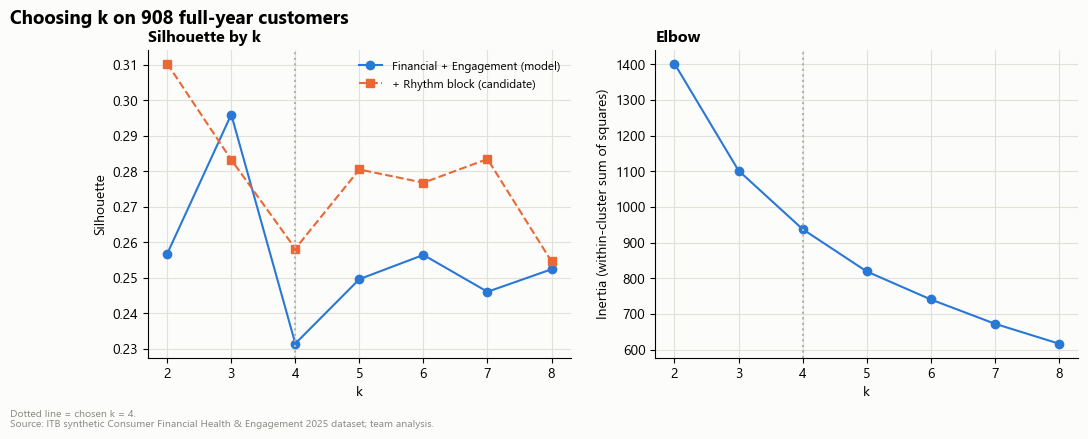

In [8]:
ks = range(2, 9)
res = []
for k in ks:
    a = KMeans(k, n_init=20, random_state=42).fit(X_final)
    b = KMeans(k, n_init=20, random_state=42).fit(X_rhythm)
    res.append({"k": k, "silhouette": silhouette_score(X_final, a.labels_), "silhouette_rhythm": silhouette_score(X_rhythm, b.labels_),
                "inertia": a.inertia_, "sizes": sorted(np.bincount(a.labels_).tolist(), reverse=True)})
res = pd.DataFrame(res).set_index("k")
res["inertia_drop"] = -res.inertia.diff()
print(res.round(3))
res.to_csv(OUT / "t4_k_selection.csv")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ax = axes[0]
ax.plot(res.index, res.silhouette, "o-", color=BLUE, label="Financial + Engagement (model)")
ax.plot(res.index, res.silhouette_rhythm, "s--", color=ORANGE, label="+ Rhythm block (candidate)")
ax.axvline(4, color=GRAY, ls=":"); ax.set_xlabel("k"); ax.set_ylabel("Silhouette"); ax.legend(fontsize=8.5)
ax.set_title("Silhouette by k")
ax = axes[1]
ax.plot(res.index, res.inertia, "o-", color=BLUE); ax.axvline(4, color=GRAY, ls=":")
ax.set_xlabel("k"); ax.set_ylabel("Inertia (within-cluster sum of squares)"); ax.set_title("Elbow")
finish(fig, "Choosing k on 908 full-year customers", "Dotted line = chosen k = 4.")

**Decision: k = 4 on the financial + engagement blocks.**
- Silhouette is modest at every k (0.23–0.30). Full-year customers form a continuum (HDBSCAN agrees, §2.5), so no k is "natural". k is chosen for business meaning and stability, with the elbow as a guide.
- **k = 3** has the best silhouette (0.296), but it **merges the Healthy Core with the Stretched but Highly Engaged customers** into one large group (crosstab below). That hides exactly the health difference the brief asks about. k = 4 separates them. The inertia drop is still sizeable at k = 4 (164) and flattens afterwards (119, 79).
- Stability at k = 4 is excellent: ARI = 1.00 across 10 random seeds, and on average 0.97 (min 0.92) across 50 bootstrap 80% subsamples.
- **Rhythm block:** on the complete transaction file it slightly *raises* silhouette (k = 4: 0.258 vs 0.231). This differs from v4's result on the truncated file. It is still **not adopted**. In this synthetic data, hour-of-day is fixed by spending category (Task 1 Q4), so the gain reflects category mix, not real timing behaviour. The rhythm columns are kept for profiling only.

In [9]:
K = 4
km = KMeans(K, n_init=20, random_state=42).fit(X_final)
fy["cluster"] = km.labels_
print("Cluster sizes:", np.bincount(km.labels_).tolist(), "| silhouette:", round(silhouette_score(X_final, km.labels_), 3))

# Stability: other seeds, and bootstrap 80% subsamples predicted back on all customers
seed_ari = [adjusted_rand_score(km.labels_, KMeans(K, n_init=20, random_state=s).fit_predict(X_final)) for s in range(1, 11)]
rng = np.random.default_rng(0); boot = []
for _ in range(50):
    idx = rng.choice(len(X_final), int(0.8 * len(X_final)), replace=False)
    boot.append(adjusted_rand_score(km.labels_, KMeans(K, n_init=10, random_state=0).fit(X_final[idx]).predict(X_final)))
print(f"Stability ARI across 10 seeds: mean {np.mean(seed_ari):.3f}, min {np.min(seed_ari):.3f}")
print(f"Stability ARI, 50 bootstrap 80% subsamples: mean {np.mean(boot):.3f}, min {np.min(boot):.3f}")

Cluster sizes: [199, 226, 184, 299] | silhouette: 0.231
Stability ARI across 10 seeds: mean 1.000, min 1.000
Stability ARI, 50 bootstrap 80% subsamples: mean 0.966, min 0.921


### 2.4 Naming the clusters (data-driven, not by cluster number)
K-Means cluster numbers are arbitrary, so names are assigned by rules on the centroids, using the dataset's own scores for interpretation:
1. **Stretched but Highly Engaged**: the cluster with the lowest mean `financial_health_score`
2. **Low Engagement & Financially Vulnerable**: among the rest, the fewest transactions per month
3. **Emerging Digital Customers**: among the rest, the youngest
4. **Financially Healthy Core**: the remaining cluster

The partial-year customers become the fifth segment, **New / Low-history**.

In [10]:
prof0 = fy.groupby("cluster")[["avg_health_score", "avg_txn_count", "age"]].mean()
names = {}
rest = list(prof0.index)
for label, col, fn in [("Stretched but Highly Engaged", "avg_health_score", "idxmin"),
                       ("Low Engagement & Financially Vulnerable", "avg_txn_count", "idxmin"),
                       ("Emerging Digital Customers", "age", "idxmin")]:
    cid = getattr(prof0.loc[rest, col], fn)(); names[cid] = label; rest.remove(cid)
names[rest[0]] = "Financially Healthy Core"
fy["segment"] = fy.cluster.map(names)
cust["segment"] = fy.segment.reindex(cust.index).fillna("New / Low-history")
ORDER = ["Financially Healthy Core", "Emerging Digital Customers", "Stretched but Highly Engaged",
         "Low Engagement & Financially Vulnerable", "New / Low-history"]
SEG_COL = dict(zip(ORDER, [BLUE, AQUA, ORANGE, VIOLET, GRAY]))
SHORT = dict(zip(ORDER, ["Healthy Core", "Emerging Digital", "Stretched & Engaged", "Low-Engagement Vulnerable", "New / Low-history"]))
sizes = cust.segment.value_counts().reindex(ORDER)
print(pd.DataFrame({"customers": sizes, "share": (sizes / len(cust)).round(3)}))
print("Coverage:", int(sizes.sum()), "/", len(cust), "| every customer has exactly one segment:", cust.segment.notna().all())

                                         customers  share
segment                                                  
Financially Healthy Core                       299  0.299
Emerging Digital Customers                     184  0.184
Stretched but Highly Engaged                   226  0.226
Low Engagement & Financially Vulnerable        199  0.199
New / Low-history                               91  0.091
Coverage: 999 / 999 | every customer has exactly one segment: True


In [11]:
# Why not k = 3 (best silhouette)? See which k = 4 segments it merges
k3 = KMeans(3, n_init=20, random_state=42).fit_predict(X_final)
ct = pd.crosstab(fy.segment, k3, margins=True).reindex(ORDER[:4] + ["All"])
print(ct)
m3 = fy.assign(k3=k3).groupby("k3")[["avg_health_score", "low60_share", "avg_spend_income_ratio"]].mean().round(3)
print(m3)

col_0                                      0    1    2  All
segment                                                    
Financially Healthy Core                 294    1    4  299
Emerging Digital Customers                 0  184    0  184
Stretched but Highly Engaged             201    8   17  226
Low Engagement & Financially Vulnerable    0    0  199  199
All                                      495  193  220  908
    avg_health_score  low60_share  avg_spend_income_ratio
k3                                                       
0             66.621        0.230                   0.676
1             67.196        0.172                   0.681
2             65.094        0.290                   0.773


### 2.5 Cross-checks
- **Rule-based 2×2 matrix** (brief's suggested alternative): health = given score above/below the full-year median, engagement = given score above/below the median. Agreement is measured with the Adjusted Rand Index (ARI: 1 = identical partitions, 0 = chance).
- **HDBSCAN**: density-based clustering, to see whether clear density gaps exist.
- **Link to Tasks 2 and 3**: where the *stressed but highly engaged* (Task 2) and *healthy but disengaged* (Task 3) customers land.

In [12]:
hm, em = fy.avg_health_score.median(), fy.avg_engagement_score.median()
fy["matrix_2x2"] = np.where(fy.avg_health_score >= hm, "High health", "Low health") + " / " + \
                   np.where(fy.avg_engagement_score >= em, "High eng.", "Low eng.")
print(pd.crosstab(fy.segment, fy.matrix_2x2).reindex(ORDER[:4]))
print("ARI (K-Means vs 2x2 matrix):", round(adjusted_rand_score(fy.segment, fy.matrix_2x2), 3))

hdb = HDBSCAN(min_cluster_size=20).fit_predict(X_final)
print("\nHDBSCAN on full-year customers:", pd.Series(hdb).value_counts().to_dict())

# Task 2 rule: score < 60 in >= 25% of months AND mean engagement >= 80
cust["stressed_engaged"] = (cust.low60_share >= 0.25) & (cust.avg_engagement_score >= 80)
# Task 3 rule: mean health >= P67 AND mean engagement <= P25 (percentiles of all 999)
cust["healthy_disengaged"] = (cust.avg_health_score >= cust.avg_health_score.quantile(0.67)) & \
                             (cust.avg_engagement_score <= cust.avg_engagement_score.quantile(0.25))
print("\nTask 2/3 groups by segment:")
print(cust.groupby("segment")[["stressed_engaged", "healthy_disengaged"]].sum().reindex(ORDER).astype(int))

matrix_2x2                               High health / High eng.  High health / Low eng.  Low health / High eng.  Low health / Low eng.
segment                                                                                                                                
Financially Healthy Core                                     124                     128                      27                     20
Emerging Digital Customers                                    80                      23                      66                     15
Stretched but Highly Engaged                                   9                       2                     144                     71
Low Engagement & Financially Vulnerable                        2                      86                       3                    108
ARI (K-Means vs 2x2 matrix): 0.225

HDBSCAN on full-year customers: {-1: 445, 2: 384, 0: 52, 1: 27}

Task 2/3 groups by segment:
                                         stressed_engag

C:\Users\TAM\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\cluster\_hdbscan\hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(


**Reading the cross-checks**
- **2×2 matrix: ARI = 0.225 (moderate).** The segments sit where expected on the matrix:
  - Stretched but Highly Engaged: 215 of 226 (95%) are below the health median.
  - Low Engagement & Financially Vulnerable: 194 of 199 (97%) are below the engagement median.
  - Healthy Core: 252 of 299 (84%) are above the health median.
  - Emerging Digital: straddles the health median, but 146 of 184 (79%) are above the engagement median.

  ARI stays modest because K-Means also uses spending *structure* (essential ratio, volatility), which a matrix on two scores cannot see.
- **HDBSCAN:** 445 of 908 customers are labelled noise, and the rest forms small dense pockets. There are no clear density gaps: the segments partition a continuum (Limitation 2).
- **Consistency with Tasks 2-3:**
  - Of the 106 *stressed but highly engaged* customers (Task 2), 56 are in Stretched but Highly Engaged and 33 in Emerging Digital.
  - Of the 85 *healthy but disengaged* customers (Task 3), 39 are in Low Engagement & Financially Vulnerable, 32 in New / Low-history and 12 in Healthy Core. A segment name describes its average; about 1 in 5 Low-Engagement members (39/199) are financially healthy and are the retention sub-target from Task 3.

## 3. Customer Profiling

In [13]:
metrics = {"avg_health_score": "Financial health score", "low60_share": "Share of months < 60",
           "avg_spend_income_ratio": "Spend-to-income", "avg_utilization": "Credit utilisation",
           "avg_essential_ratio": "Essential ratio", "avg_volatility": "Spending volatility",
           "balance_trend_norm": "Balance trend / income", "avg_engagement_score": "Engagement score",
           "avg_txn_count": "Txns / month", "avg_active_days": "Active days / month",
           "avg_online_ratio": "Online spend ratio", "avg_recency": "Recency (days)",
           "avg_category_diversity": "Categories / month", "age": "Age", "crisis_next_rate": "Next-month crisis rate (<40)"}
prof = cust.groupby("segment")[list(metrics)].mean().reindex(ORDER)
prof.insert(0, "customers", sizes)
prof.insert(1, "% customers", (sizes / len(cust) * 100).round(1))
prof.insert(2, "% spend", (cust.groupby("segment").total_spend.sum() / cust.total_spend.sum() * 100).reindex(ORDER).round(1))
overall_fy = cust.loc[FY, list(metrics)].mean().rename("Full-year average")
table = pd.concat([prof.rename(columns=metrics), overall_fy.rename(metrics).to_frame().T])
table.to_csv(OUT / "t4_segment_profile.csv")
table.round(3)

,customers,% customers,% spend,Financial health score,Share of months < 60,Spend-to-income,Credit utilisation,Essential ratio,Spending volatility,Balance trend / income,Engagement score,Txns / month,Active days / month,Online spend ratio,Recency (days),Categories / month,Age,Next-month crisis rate (<40)
Financially Healthy Core,299.0,29.9,32.4,69.283,0.145,0.589,0.151,0.510,1.764,4.952,78.414,190.315,29.761,0.193,0.015,13.862,53.391,0.000
Emerging Digital Customers,184.0,18.4,31.9,67.423,0.163,0.674,0.183,0.401,1.159,3.937,80.477,210.850,29.705,0.232,0.017,13.923,35.587,0.000
Stretched but Highly Engaged,226.0,22.6,26.8,62.441,0.362,0.811,0.234,0.508,1.810,2.305,79.223,203.511,30.001,0.204,0.012,13.879,51.031,0.010
Low Engagement & Financially Vulnerable,199.0,19.9,8.5,65.498,0.279,0.766,0.213,0.493,1.390,2.887,74.059,63.299,25.461,0.206,0.180,13.227,53.528,0.021
New / Low-history,91.0,9.1,0.4,65.599,0.220,0.619,0.176,0.154,0.685,0.402,48.685,9.676,1.923,0.654,13.176,4.929,58.385,0.000
Full-year average,NaN,NaN,NaN,66.373,0.232,0.700,0.192,0.484,1.571,3.635,78.079,169.924,28.867,0.206,0.051,13.739,49.226,0.007


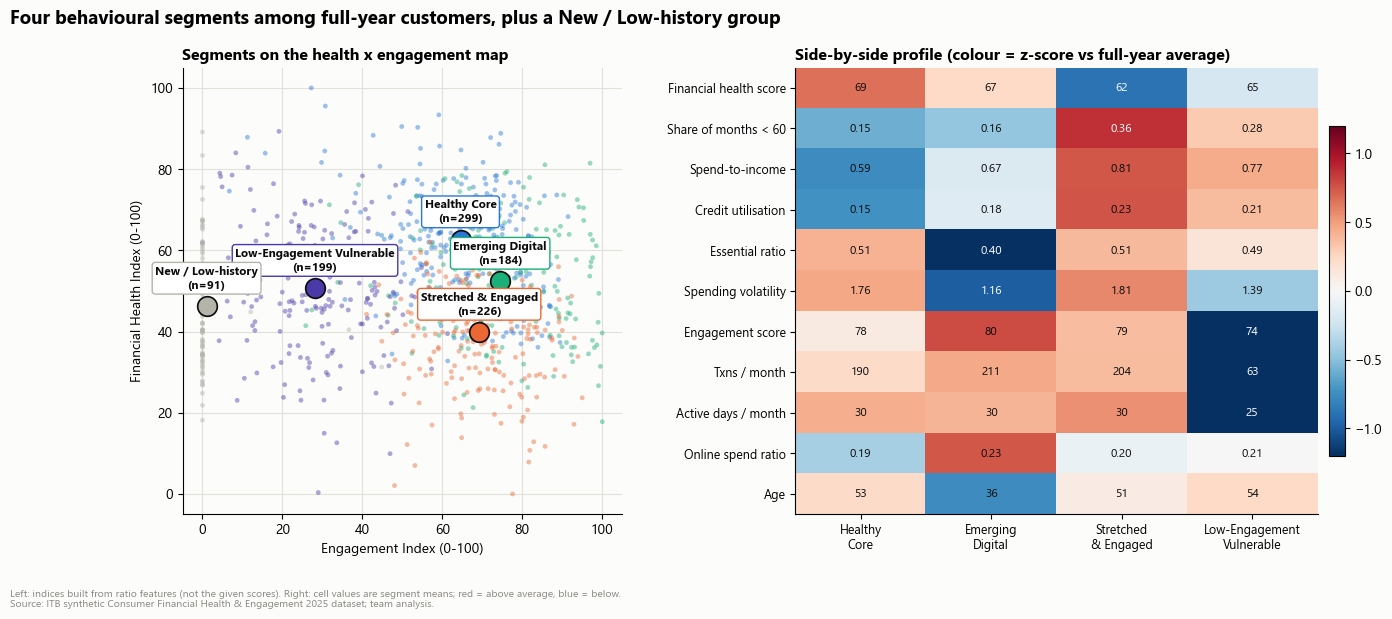

In [14]:
# Map: indices with centroids (left) and side-by-side z-score heatmap of full-year segments (right)
fig, axes = plt.subplots(1, 2, figsize=(15, 5.8), gridspec_kw={"width_ratios": [1, 1.25], "wspace": 0.35})
ax = axes[0]
for s in ORDER:
    sub = cust[cust.segment == s]
    ax.scatter(sub.EngagementIndex, sub.FinancialHealthIndex, s=12, alpha=0.45, color=SEG_COL[s], edgecolor="none")
for s in ORDER:
    sub = cust[cust.segment == s]
    ex, fh = sub.EngagementIndex.mean(), sub.FinancialHealthIndex.mean()
    ax.scatter(ex, fh, s=200, color=SEG_COL[s], edgecolor=INK, lw=1.2, zorder=4)
    ax.annotate(f"{SHORT[s]}\n(n={len(sub)})", (ex, fh), xytext=(0, 13), textcoords="offset points", ha="center",
                fontsize=8.5, fontweight="bold", color=INK, bbox=dict(boxstyle="round,pad=0.25", fc="white", ec=SEG_COL[s]), zorder=5)
ax.set_xlabel("Engagement Index (0-100)"); ax.set_ylabel("Financial Health Index (0-100)")
ax.set_title("Segments on the health x engagement map")
ax = axes[1]
show = ["avg_health_score", "low60_share", "avg_spend_income_ratio", "avg_utilization", "avg_essential_ratio",
        "avg_volatility", "avg_engagement_score", "avg_txn_count", "avg_active_days", "avg_online_ratio", "age"]
fyp = cust[FY].groupby("segment")[show].mean().reindex(ORDER[:4])
zz = (fyp - cust.loc[FY, show].mean()) / cust.loc[FY, show].std()
im = ax.imshow(zz.T.values, cmap="RdBu_r", vmin=-1.2, vmax=1.2, aspect="auto")
ax.set_xticks(range(4), [SHORT[s].replace(" ", "\n", 1) for s in zz.index], fontsize=9)
ax.set_yticks(range(len(show)), [metrics[m] for m in show], fontsize=9); ax.grid(False)
for i in range(len(show)):
    for j in range(4):
        v = fyp.iloc[j, i]
        ax.text(j, i, f"{v:.2f}" if abs(v) < 10 else f"{v:.0f}", ha="center", va="center", fontsize=8.5,
                color="white" if abs(zz.iloc[j, i]) > 0.8 else INK)
ax.set_title("Side-by-side profile (colour = z-score vs full-year average)")
fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
finish(fig, "Four behavioural segments among full-year customers, plus a New / Low-history group",
       "Left: indices built from ratio features (not the given scores). Right: cell values are segment means; red = above average, blue = below.")

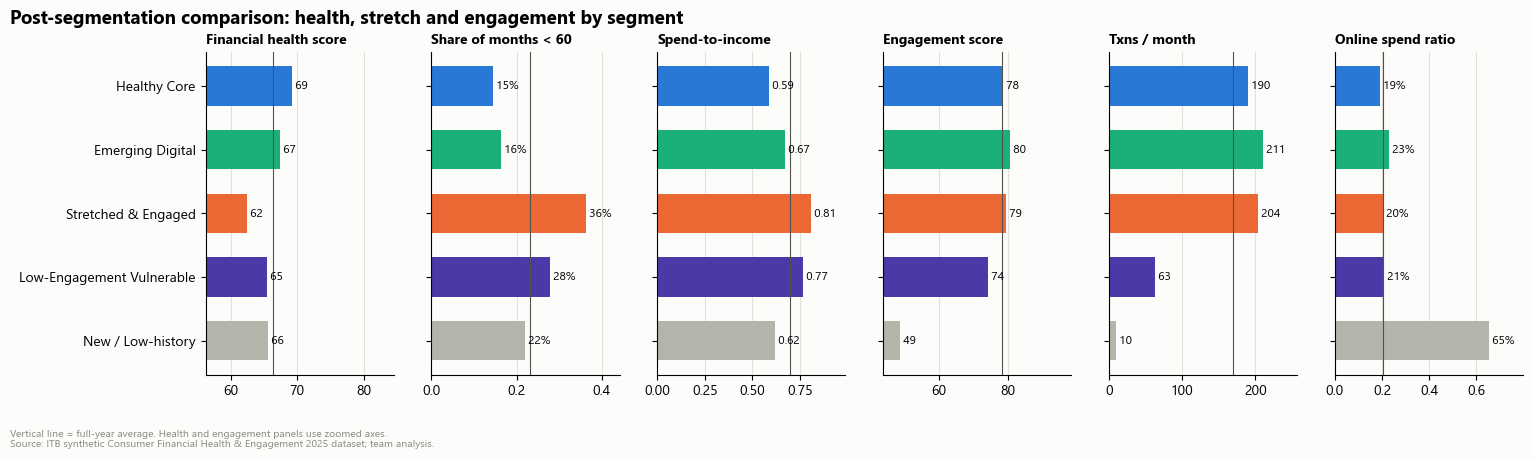

In [15]:
# Key differences in one row of small multiples (given scores and the main drivers)
keys = [("avg_health_score", "Financial health score", None), ("low60_share", "Share of months < 60", "pct"),
        ("avg_spend_income_ratio", "Spend-to-income", None), ("avg_engagement_score", "Engagement score", None),
        ("avg_txn_count", "Txns / month", None), ("avg_online_ratio", "Online spend ratio", "pct")]
fig, axes = plt.subplots(1, len(keys), figsize=(17, 4.2), sharey=True)
y = np.arange(len(ORDER))[::-1]
for ax, (col, lab, fmt) in zip(axes, keys):
    v = prof[col].values
    ax.barh(y, v, color=[SEG_COL[s] for s in ORDER], height=0.62)
    ax.axvline(cust.loc[FY, col].mean(), color=INK_2, lw=0.8)
    for yi, vi in zip(y, v):
        ax.text(vi, yi, f" {vi:.0%}" if fmt == "pct" else f" {vi:.0f}" if col in ("avg_txn_count", "avg_health_score", "avg_engagement_score") else f" {vi:.2f}", va="center", fontsize=8.5)
    lo_ = 0 if col in ("low60_share", "avg_txn_count", "avg_online_ratio", "avg_spend_income_ratio") else min(v) * 0.9
    ax.set_xlim(lo_, max(v) * 1.22); ax.set_title(lab, fontsize=10); ax.grid(axis="y", visible=False)
axes[0].set_yticks(y, [SHORT[s] for s in ORDER])
finish(fig, "Post-segmentation comparison: health, stretch and engagement by segment",
       "Vertical line = full-year average. Health and engagement panels use zoomed axes.")

**Segment profiles** (full-year average in brackets)
- **Financially Healthy Core: 299 customers (29.9%), 32.4% of spend.**
  - Best financial health: 69.3 (66.4); only 14.5% of months below 60 (23.2%).
  - Lowest spend-to-income (0.59) and credit utilisation (0.15). Engagement is average (78.4).
  - Older (mean 53) and over-represented in Engineering & IT (22.7%).
- **Emerging Digital Customers: 184 (18.4%), 31.9% of spend**, the highest spend per customer.
  - Youngest segment (mean 36; 69% aged 25-44, none aged 55+).
  - Most engaged: 80.5 engagement, 211 transactions/month, and the highest online ratio among full-year customers (23% vs 21%).
  - Lowest essential ratio (0.40) and volatility (1.16). Health is above average (67.4).
- **Stretched but Highly Engaged: 226 (22.6%), 26.8% of spend.**
  - Lowest health: 62.4, with **36% of months below 60**.
  - Highest spend-to-income (0.81), credit utilisation (0.23) and volatility (1.81).
  - Still very active: 79.2 engagement and 204 transactions/month. This is the Task 2 profile at scale.
- **Low Engagement & Financially Vulnerable: 199 (19.9%), 8.5% of spend.**
  - Fewest transactions (63 vs 170) and active days (25.5 vs 28.9), longest recency, lowest engagement (74.1).
  - Health below average: 65.5, 28% of months below 60, spend-to-income 0.77.
  - Highest next-month crisis rate (2.1%).
- **New / Low-history: 91 (9.1%), 0.4% of spend.**
  - Only 1-2 observed months and about 10 transactions per month. Their averages are not comparable with the other segments (e.g. a 65% online ratio on very few transactions).

### 3.1 Demographic profile (description only, never a clustering input)

In [16]:
print("=== Age group (row %) ===")
print((pd.crosstab(cust.segment, cust.age_group, normalize="index") * 100).reindex(ORDER).round(1))
print("\n=== Gender (row %) ===")
print((pd.crosstab(cust.segment, cust.gender, normalize="index") * 100).reindex(ORDER).round(1))
print("\n=== Occupation group (row %, 10 keyword groups from Task 2) ===")
print((pd.crosstab(cust.segment, cust.occupation_group, normalize="index") * 100).reindex(ORDER).round(1))
prov = pd.crosstab(cust.segment, cust.province_city, normalize="index").reindex(ORDER)
print("\n=== Province concentration: largest single-province share per segment ===")
print(pd.DataFrame({"top province": prov.idxmax(axis=1), "share %": (prov.max(axis=1) * 100).round(1)}))

=== Age group (row %) ===
age_group                                <18  18-24  25-34  35-44  45-54  55-64   65+
segment                                                                              
Financially Healthy Core                 0.7    6.0   12.7   12.0   19.7   22.1  26.8
Emerging Digital Customers               2.2    9.8   33.2   35.9   19.0    0.0   0.0
Stretched but Highly Engaged             0.4    2.2   17.7   16.8   24.3   15.5  23.0
Low Engagement & Financially Vulnerable  0.0    1.5   19.1   12.6   18.6   23.1  25.1
New / Low-history                        0.0   19.8    0.0    0.0   13.2   30.8  36.3

=== Gender (row %) ===
gender                                    Nam    Nữ
segment                                            
Financially Healthy Core                 44.5  55.5
Emerging Digital Customers               45.1  54.9
Stretched but Highly Engaged             51.8  48.2
Low Engagement & Financially Vulnerable  57.8  42.2
New / Low-history                   

**Reading the demographic profile**
- **Age is the main demographic difference, and it follows behaviour** (demographics were never model inputs). Emerging Digital has no customers aged 55+, while Healthy Core and Low-Engagement are about 50% aged 55+. New / Low-history is 20% aged 18-24 and 67% aged 55+.
- **Gender** is fairly balanced (45-58% male). Low-Engagement leans male (57.8%).
- **Occupation** (10 groups from Task 2), compared with the overall shares of 18% Media and 14% Engineering & IT:
  - Stretched over-represents *Media, arts & design* (25.2%) and under-represents *Engineering & IT* (5.8%).
  - Healthy Core shows the reverse (22.7% Engineering & IT).
  - This matches the occupation gap found in Task 2.
- **Province:** no segment is geographically concentrated. The largest single province (TP. Hồ Chí Minh) holds 8-18% of every segment.
- **Fairness:** offers built for one segment must not systematically exclude an age group from beneficial features. Segments are used for support, not for eligibility.

## 4. Post-Segmentation Analysis & Business Recommendations
Every action is **non-punitive**. `financial_health_score` and segment membership are used only to offer support, education and relevant features. They are **never** used to approve or deny credit, cut a limit or block an account.

In [17]:
def seg(s, col): return prof.loc[s, col]
fyavg = cust.loc[FY]
recs = pd.DataFrame([
    {"segment": "Stretched but Highly Engaged", "priority": 1,
     "evidence": f"spend-to-income {seg('Stretched but Highly Engaged','avg_spend_income_ratio'):.2f} vs {fyavg.avg_spend_income_ratio.mean():.2f}; "
                 f"{seg('Stretched but Highly Engaged','low60_share'):.0%} of months < 60",
     "tools": "Budgeting tool + spend alerts",
     "action": "In-app monthly budget with an alert when projected spend passes ~80% of income; pre-December planning reminder."},
    {"segment": "Low Engagement & Financially Vulnerable", "priority": 2,
     "evidence": f"{seg('Low Engagement & Financially Vulnerable','avg_txn_count'):.0f} txns/month vs {fyavg.avg_txn_count.mean():.0f}; "
                 f"{seg('Low Engagement & Financially Vulnerable','low60_share'):.0%} of months < 60",
     "tools": "Financial-education content + digital-channel nudges",
     "action": "Short money-management content plus first-use incentives for QR / app payments on everyday categories."},
    {"segment": "New / Low-history", "priority": 3,
     "evidence": f"only 1-2 observed months; {seg('New / Low-history','avg_txn_count'):.0f} txns/month",
     "tools": "Onboarding / digital-channel nudges",
     "action": "Second-month activation journey: set up recurring bills and app wallet, welcome-back offer."},
    {"segment": "Emerging Digital Customers", "priority": 4,
     "evidence": f"age {seg('Emerging Digital Customers','age'):.0f} vs {fyavg.age.mean():.0f}; online ratio "
                 f"{seg('Emerging Digital Customers','avg_online_ratio'):.0%} vs {fyavg.avg_online_ratio.mean():.0%}",
     "tools": "Suitable product suggestions + planning reminders",
     "action": "Digital savings goals and round-ups; keep them healthy as spending grows."},
    {"segment": "Financially Healthy Core", "priority": 5,
     "evidence": f"health {seg('Financially Healthy Core','avg_health_score'):.1f}; spend-to-income "
                 f"{seg('Financially Healthy Core','avg_spend_income_ratio'):.2f}",
     "tools": "Suitable product suggestions",
     "action": "Rewards and savings products; share-of-wallet offers for the less active members (Task 3 healthy-but-disengaged)."},
])
recs["customers"] = recs.segment.map(sizes)
recs["% customers"] = (recs.customers / len(cust) * 100).round(1)
recs = recs[["priority", "segment", "customers", "% customers", "evidence", "tools", "action"]]
recs.to_csv(OUT / "t4_recommendations.csv", index=False, encoding="utf-8-sig")
with pd.option_context("display.max_colwidth", 120):
    display(recs)

,priority,segment,customers,% customers,evidence,tools,action
0,1,Stretched but Highly Engaged,226,22.6,spend-to-income 0.81 vs 0.70; 36% of months < 60,Budgeting tool + spend alerts,In-app monthly budget with an alert when projected spend passes ~80% of income; pre-December planning reminder.
1,2,Low Engagement & Financially Vulnerable,199,19.9,63 txns/month vs 170; 28% of months < 60,Financial-education content + digital-channel nudges,Short money-management content plus first-use incentives for QR / app payments on everyday categories.
2,3,New / Low-history,91,9.1,only 1-2 observed months; 10 txns/month,Onboarding / digital-channel nudges,"Second-month activation journey: set up recurring bills and app wallet, welcome-back offer."
3,4,Emerging Digital Customers,184,18.4,age 36 vs 49; online ratio 23% vs 21%,Suitable product suggestions + planning reminders,Digital savings goals and round-ups; keep them healthy as spending grows.
4,5,Financially Healthy Core,299,29.9,health 69.3; spend-to-income 0.59,Suitable product suggestions,Rewards and savings products; share-of-wallet offers for the less active members (Task 3 healthy-but-disengaged).


**How the priorities were set:** by how directly the segment's gap links to the main health driver (spend-to-income explains 81% of the score, Task 2) and by reach.
1. **Stretched but Highly Engaged (226, 22.6%): budgeting tool + spend alerts.** This is the strongest lever: highest spend-to-income (0.81) and 36% of months below 60, and they are in the app every day. Add a pre-December planning reminder, since December spend-to-income is 1.25 (Task 1 Q1).
2. **Low Engagement & Financially Vulnerable (199, 19.9%): financial-education content + digital-channel nudges.** Low activity plus below-average health. The 39 healthy-but-disengaged members inside are the Task 3 retention target.
3. **New / Low-history (91, 9.1%): onboarding nudges.** A second-month activation journey (recurring bills, app wallet) to turn a trial into a relationship.
4. **Emerging Digital Customers (184, 18.4%; 31.9% of spend): suitable product suggestions + planning reminders.** They are high-value and healthy. Digital savings goals and round-ups help keep spend-to-income (0.67) in check as they grow.
5. **Financially Healthy Core (299, 29.9%): suitable product suggestions.** Rewards and savings products, and share-of-wallet offers for its 12 healthy-but-disengaged members.

**Credit-decision rule:** segment labels and `financial_health_score` are used only to offer support, education and relevant features. They are **never** used to approve or deny credit, reduce a credit limit or block an account. Task 5 expands these ideas across all six tool types.

## 5. Limitations and Future Work
**Limitations**
1. **Static averages:** each customer is one 12-month mean vector, so seasonality (e.g. the December spike in Task 1) is averaged away.
2. **Continuum, not discrete types:** silhouette is modest and HDBSCAN finds no strong density gaps among full-year customers. The four segments are a *useful partition of a continuum*, not naturally separate populations.
3. **Partial-year customers are rule-assigned:** 91 customers with only 1-2 months cannot be profiled reliably. Their segment is defined by data length, and they may include both late joiners and early leavers.
4. **Circularity:** the given `financial_health_score` is very likely built from the same ratios (Task 2: spend-to-income alone explains 81% of it), so agreement between segments and the score partly reflects construction.
5. **Synthetic data:** income, limits and balances are synthetic, so only ratios are compared. Hour-of-day features are generation artefacts.
6. **Fairness:** age differs strongly by segment (a behavioural consequence, not an input). Any campaign should be checked so that older or younger customers are not systematically excluded from beneficial offers.

**Future work**
- Model trajectories (month-to-month migration between segments) instead of yearly averages, and track migration as a KPI.
- Try soft assignment (GMM) given the continuum, and report membership probabilities for borderline customers.
- Add channel-mix and category-mix features from the transaction file as a further candidate block.
- Re-segment quarterly, and A/B-test the recommended interventions per segment.

In [18]:
keep = ["segment", "full_year", "n_months", "age", "age_group", "gender", "occupation", "occupation_group", "province_city",
        "FinancialHealthIndex", "EngagementIndex", "stressed_engaged", "healthy_disengaged"] + list(metrics) + \
       fin_features + eng_features + rhythm_features
cust[[k for k in dict.fromkeys(keep)]].to_csv(OUT / "customer_segments.csv", encoding="utf-8-sig")
print("Saved", OUT / "customer_segments.csv", "-", len(cust), "customers, 100% coverage,", cust.segment.nunique(), "segments.")

Saved D:\Đại học\Cuộc thi Data\Business Intelligence 2026\Vòng 1\outputs_task4\customer_segments.csv - 999 customers, 100% coverage, 5 segments.
